In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [4]:
words = open('names.txt','r').read().splitlines()
words[0:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [5]:
#build the dataset
X,Y = [],[]
block_size = 3
for w in words[0:5]:
    print(w)
    context = [0] * block_size
    
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->',itos[ix])
        #print(context)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [7]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [8]:
C = torch.randn((27,2))

In [9]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [10]:
W = torch.randn((6,100))
b1 = torch.randn(100)

In [11]:
W.shape, b1.shape

(torch.Size([6, 100]), torch.Size([100]))

In [12]:
#emb @ W + b #mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)
emb @ W

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [13]:
emb[:,0,:].shape

torch.Size([32, 2])

In [14]:
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1)

tensor([[-1.1275, -2.0429, -1.1275, -2.0429, -1.1275, -2.0429],
        [-1.1275, -2.0429, -1.1275, -2.0429,  0.6407, -0.9347],
        [-1.1275, -2.0429,  0.6407, -0.9347,  0.8707, -2.0671],
        [ 0.6407, -0.9347,  0.8707, -2.0671,  0.8707, -2.0671],
        [ 0.8707, -2.0671,  0.8707, -2.0671,  0.9074, -0.4294],
        [-1.1275, -2.0429, -1.1275, -2.0429, -1.1275, -2.0429],
        [-1.1275, -2.0429, -1.1275, -2.0429,  1.6078,  0.7736],
        [-1.1275, -2.0429,  1.6078,  0.7736,  0.6987, -0.3518],
        [ 1.6078,  0.7736,  0.6987, -0.3518, -0.6938,  1.5104],
        [ 0.6987, -0.3518, -0.6938,  1.5104,  0.3206, -1.1393],
        [-0.6938,  1.5104,  0.3206, -1.1393, -0.6938,  1.5104],
        [ 0.3206, -1.1393, -0.6938,  1.5104,  0.9074, -0.4294],
        [-1.1275, -2.0429, -1.1275, -2.0429, -1.1275, -2.0429],
        [-1.1275, -2.0429, -1.1275, -2.0429,  0.9074, -0.4294],
        [-1.1275, -2.0429,  0.9074, -0.4294,  0.3206, -1.1393],
        [ 0.9074, -0.4294,  0.3206, -1.1

In [15]:
torch.cat(torch.unbind(emb,1),1).shape # unbind gives list of tensor without that dimension

torch.Size([32, 6])

In [ ]:
emb.view(32,6) == torch.cat(torch.unbind(emb,1),1)

In [ ]:
emb.view(32,6) @ W + b1

In [134]:
(emb.view(-1,6) @ W + b1).shape # -1 will infer the value based. emb(32,6) W(6,100)

torch.Size([32, 100])

In [ ]:
h = emb.view(-1,6) @ W + b1
h

In [22]:
h = torch.tanh(emb.view(-1,6) @ W + b1)
h.shape

torch.Size([32, 100])

In [23]:
# Output Layer
W2 = torch.randn(100,27)
b2 = torch.randn(27)

In [24]:
logits = h @ W2 + b2 #(32,100) @ (100,27) + (,27) ==> (32,27)

In [25]:
counts = logits.exp()

In [26]:
prob = counts / counts.sum(1, keepdim = True)

In [27]:
prob.shape

torch.Size([32, 27])

In [17]:
Y.shape

torch.Size([32])

In [151]:
Y # actual Letter that come next


tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
prob[torch.arange(32),Y] #prob(32,27) Y(27)

In [31]:
loss = -prob[torch.arange(32),Y].log().mean()
loss

tensor(16.4142)

In [ ]:
# Bringing Everything Together

In [72]:
X,Y = [], []
block_size = 3
for w in words:
    context = [0] * block_size
    #print(w)
    for ch in w + '.':
        X.append(context)
        ix = stoi[ch]
        Y.append(ix)
     #   print(''.join(itos[i] for i in context), '--->',ch)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [73]:
#Dataset
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [74]:
g = torch.Generator().manual_seed(2147483647) # for reproducubility
C = torch.randn((27,2), generator = g)
W1 = torch.randn((6,100), generator = g)
b1 = torch.randn((100), generator = g)
W2 = torch.randn((100, 27), generator = g)
b2 = torch.randn((27), generator = g)
parameters = [C,W1,b1,W2, b2]

In [75]:
sum(p.nelement() for p in parameters)

3481

In [ ]:
# forward pass
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim = True)
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

In [76]:
for p in parameters:
    p.requires_grad = True

In [69]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [83]:
lri = []
lossi = []

for i in range(10000):

    #minibatch construct
    ix = torch.randint(0,X.shape[0], (32,))
    
    # forward pass
    emb = C[X[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y[ix])
    #print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #lr = lrs[i]
    ls = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())
    
print(loss.item())

2.2088897228240967


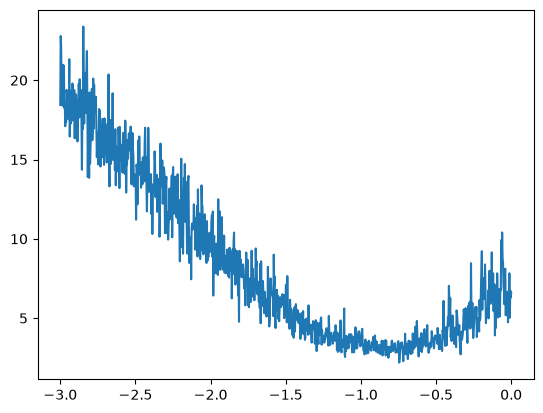

In [71]:
plt.plot(lri,lossi)

In [82]:
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) #(32,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Y)
loss

tensor(2.4819, grad_fn=<NllLossBackward0>)

In [7]:
def build_dataset(words):
    X,Y = [],[]
    block_size = 3
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
#Dataset
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [11]:
#Initialize the network
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10),generator = g)
W1 = torch.randn((30,200),generator = g)
b1 = torch.randn((200), generator = g)
W2 = torch.randn((200,27), generator = g)
b2 = torch.randn((27), generator = g)
parameters = [C, W1,b1,W2,b2]

In [10]:
sum(p.nelement() for p in parameters)

11897

In [12]:
for p in parameters:
    p.requires_grad = True

In [13]:
lri = []
stepi = []
lossi = []

In [20]:
for i in range(50000):
    #prepare mini batch
    ix = torch.randint(0, Xtr.shape[0], (32,))

    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) #(32,100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

     #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #Track Status
    lossi.append(loss.log10().item())
    stepi.append(i)
    

print(loss.item())
    

2.036250352859497


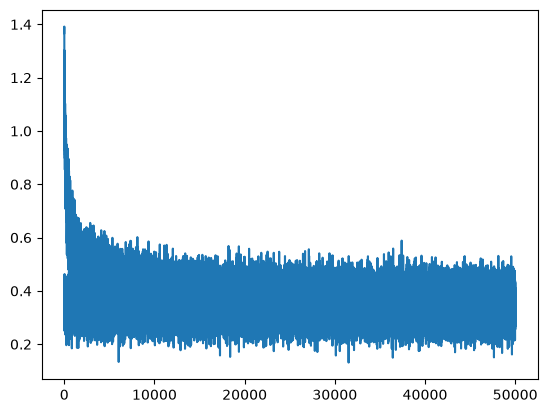

In [19]:
plt.plot(stepi,lossi)

In [21]:
emb = C[Xtr] # (32,3,2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) #(32,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.1642, grad_fn=<NllLossBackward0>)

In [22]:
emb = C[Xdev] # (32,3,2)
h = torch.tanh(emb.view(-1,30) @ W1 + b1) #(32,100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.1934, grad_fn=<NllLossBackward0>)

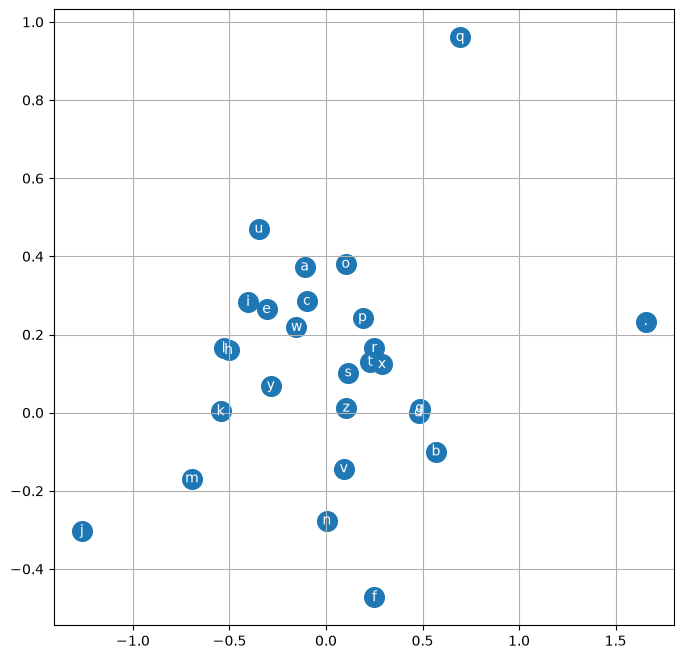

In [23]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [32]:
#Sample Ffrom the model
g = torch.Generator().manual_seed(2147483647 + 10)
block_size = 3

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] #(1,3,2)
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits,dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        out.append(ix)
        context = context[1:] + [ix]
        if ix == 0:
            break;
        
    print(''.join(itos[i] for i in out))

carpah.
amelle.
khirmin.
rehty.
halaysa.
jazhneefaresarci.
aqui.
nekoniah.
maihvik.
leigh.
ham.
joce.
quint.
shore.
alianni.
watelo.
dearixi.
jaxen.
ivrai.
edde.
